In [22]:
import numpy as np
np.random.seed(33454)
import matplotlib.pyplot as plt
plt.style.use('ggplot')

class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), k_min=0, k_max=1, granularity=11, epsilon=0.1, alpha=0.1, epsilon_decay=None):
        self.valuation_distribution = valuation_distribution
        self.k_values = np.linspace(k_min, k_max, granularity)
        self.epsilon = epsilon
        self.epsilon_initial = epsilon
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.granularity = granularity
        self.q_values = np.ones(granularity)
        self.action_counts = np.zeros(granularity)
        self.reward_history = []
        self.valuation = self.valuation_distribution()

    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.k_values)
        else:
            return self.k_values[np.argmax(self.q_values)]

    def update_q_values(self, chosen_k, reward):
        k_index = np.argmin(np.abs(self.k_values - chosen_k))
        self.action_counts[k_index] += 1
        self.q_values[k_index] += self.alpha * (reward - self.q_values[k_index])

    def feedback(self, reward, chosen_k):
        self.reward_history.append(reward)
        self.update_q_values(chosen_k, reward)
        if self.epsilon_decay:
            self.epsilon = max(0.05, self.epsilon_initial * self.epsilon_decay)

class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None, epsilon_reward=0.001):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.epsilon_reward = epsilon_reward
        self.profit_history = []

    def run_auction(self):
        for agent in self.agents: agent.refresh_valuation()
        bids = [max(self.price_floor, min(agent.choose_action() * agent.valuation, self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        for idx, agent in enumerate(self.agents):
            reward = agent.valuation - payment + self.epsilon_reward if idx == winner_index else 0
            agent.feedback(reward, bids[idx] / agent.valuation)
        self.profit_history.append(payment)
        return {"winner": winner_index, "payment": payment, "bids": bids}

def run_single_simulation(agents, game, num_rounds=10000):
    for _ in range(num_rounds): game.run_auction()
    return [agent.q_values for agent in agents]

def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    all_k_values = [[] for _ in range(len(agents))]
    for sim in range(num_simulations):
        run_single_simulation(agents, auction, num_rounds=num_rounds)
        for i, agent in enumerate(agents):
            avg_k_values = agent.k_values[np.argmax(agent.q_values)]
            all_k_values[i].append(avg_k_values)

    percentiles = {}
    for i in range(len(agents)):
        avg_k_for_agent = np.array(all_k_values[i])
        percentiles[i] = {
            "5th": np.percentile(avg_k_for_agent, 5),
            "median": np.median(avg_k_for_agent),
            "95th": np.percentile(avg_k_for_agent, 95),
        }
    return percentiles

def plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=None, figsize=(10, 10), grid_dims=(2, 2), title=None, fontsize=12):
    fig, axes = plt.subplots(grid_dims[0], grid_dims[1], figsize=figsize)
    axes = axes.flatten()
    valuations = np.linspace(0, 1, 100)  # 100 points for valuations in the range [0, 1]
    
    for i, agent in enumerate(agents):
        ax = axes[i]
        
        # Get the 5th, median, and 95th percentile learned k-values
        k_5th = percentiles[i]["5th"]
        k_median = percentiles[i]["median"]
        k_95th = percentiles[i]["95th"]
        
        # Calculate the bid functions for the three k-values
        bids_5th = k_5th * valuations
        bids_median = k_median * valuations
        bids_95th = k_95th * valuations
        
        # Plot the fan chart (shaded area between 5th and 95th percentile bids)
        ax.fill_between(valuations, bids_5th, bids_95th, color='lightgray', alpha=0.5, label='5th-95th Percentile Range')
        
        # Plot the median bid function
        ax.plot(valuations, bids_median, label='Median Bid Function', color='blue')
        
        # Plot the optimal bid function if provided
        if optimal_bid_rule:
            optimal_bids = optimal_bid_rule(valuations)
            ax.plot(valuations, optimal_bids, label='Optimal Bid Function', color='green', linestyle='--')

        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_xlabel('Valuation', fontsize=fontsize)
        ax.set_ylabel('Bid', fontsize=fontsize)
        ax.set_title(f'Agent {i+1}', fontsize=fontsize)
        ax.legend(fontsize=fontsize)
        ax.tick_params(axis='both', which='major', labelsize=fontsize)

    plt.tight_layout()
    if title: plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()


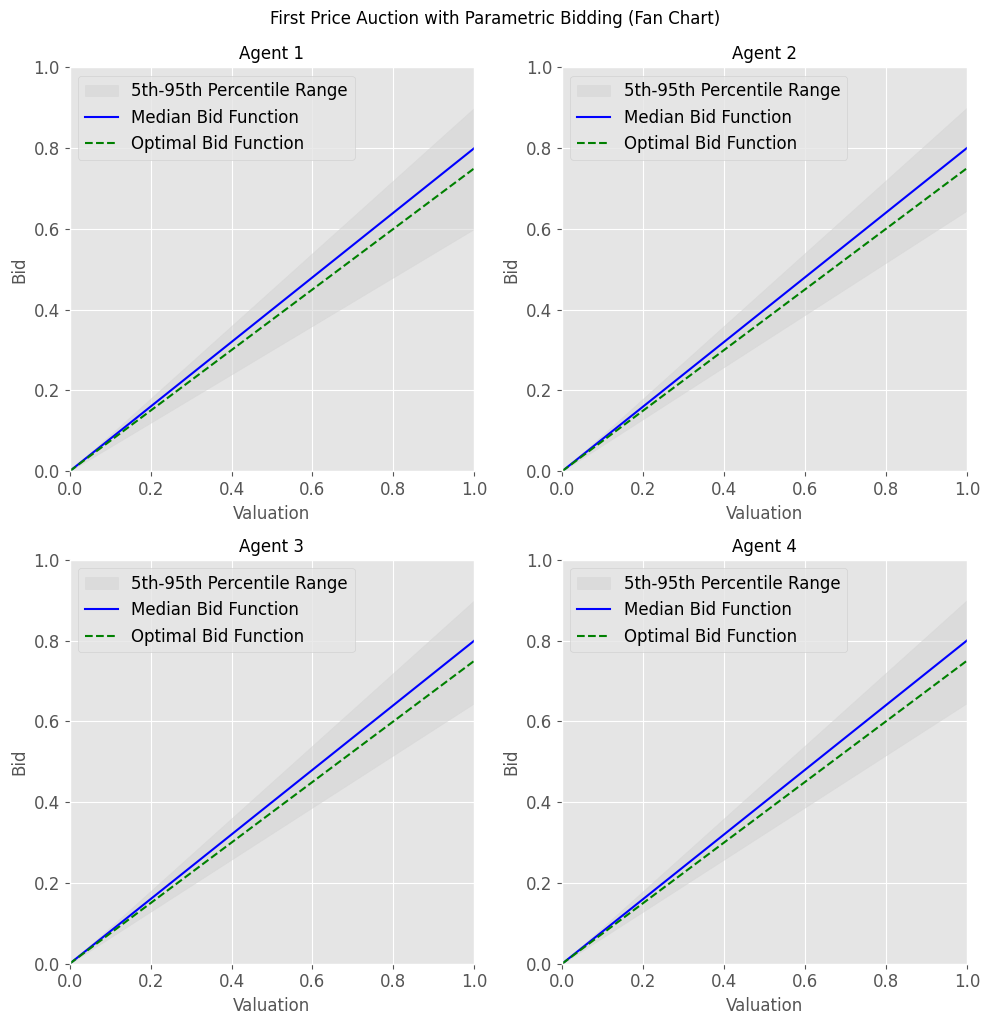

In [24]:
def first_price_rule(bids):
    highest_bid = np.max(bids)
    potential_winners = np.where(bids == highest_bid)[0]
    winner = np.random.choice(potential_winners) if len(potential_winners) > 1 else potential_winners[0]
    payment = bids[winner]
    return winner, payment

def optimal_bidding_rule(valuations, num_agents=4):
    return (num_agents - 1) / num_agents * valuations

# Run the auction and plot the results
agents = [QLearningAgent(granularity=11, epsilon = 0.1, epsilon_decay = 1.0) for _ in range(4)]
auction = SingleSidedAuction(agents, payment_rule=first_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=20000)
plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=optimal_bidding_rule, title='First Price Auction with Parametric Bidding (Fan Chart)')

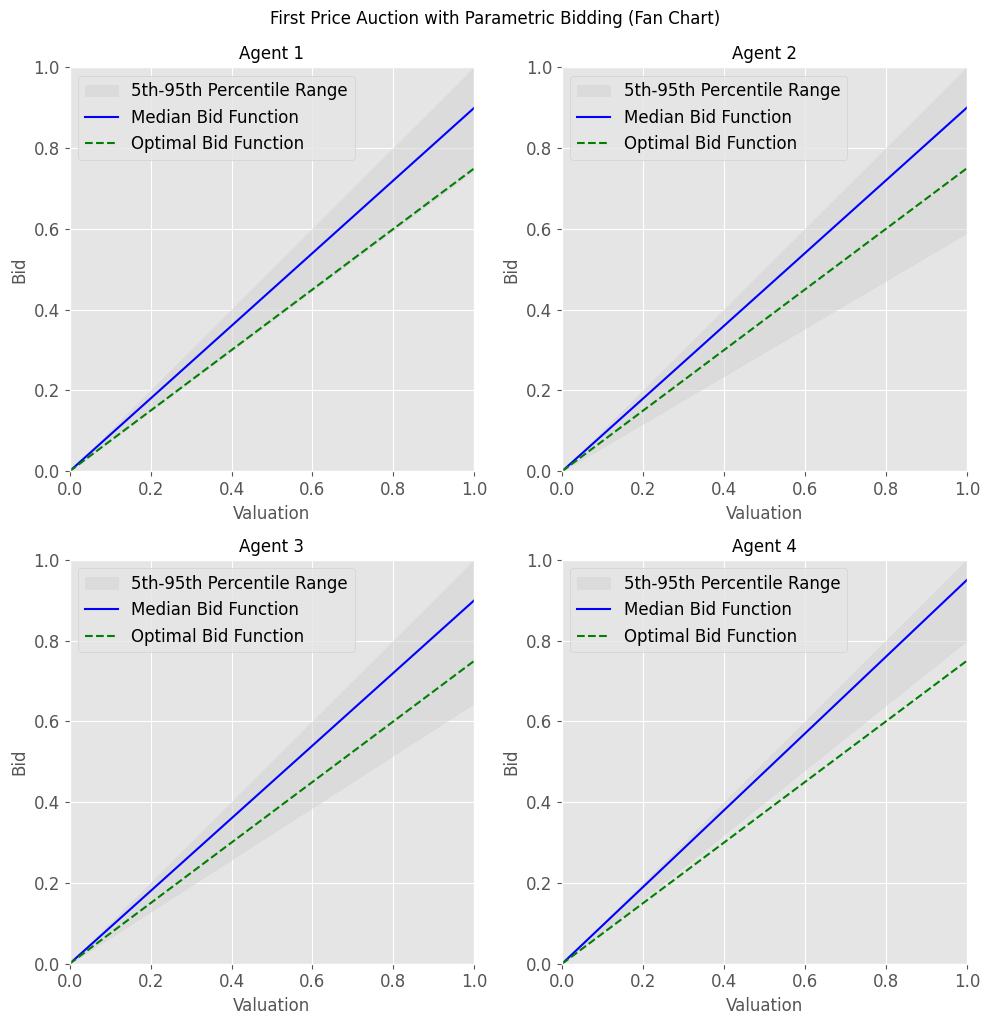

In [36]:
def second_price_rule(bids):
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
    second_highest_bid = np.partition(bids, -2)[-2]
    payment = second_highest_bid
    return winner, payment

def optimal_bid_spa(valuations, num_agents=4):
    return valuations

agents = [QLearningAgent(granularity=11, epsilon = 0.1, epsilon_decay = 1.0) for _ in range(4)]
auction = SingleSidedAuction(agents, payment_rule=second_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=20000)
plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=optimal_bidding_rule, title='First Price Auction with Parametric Bidding (Fan Chart)')

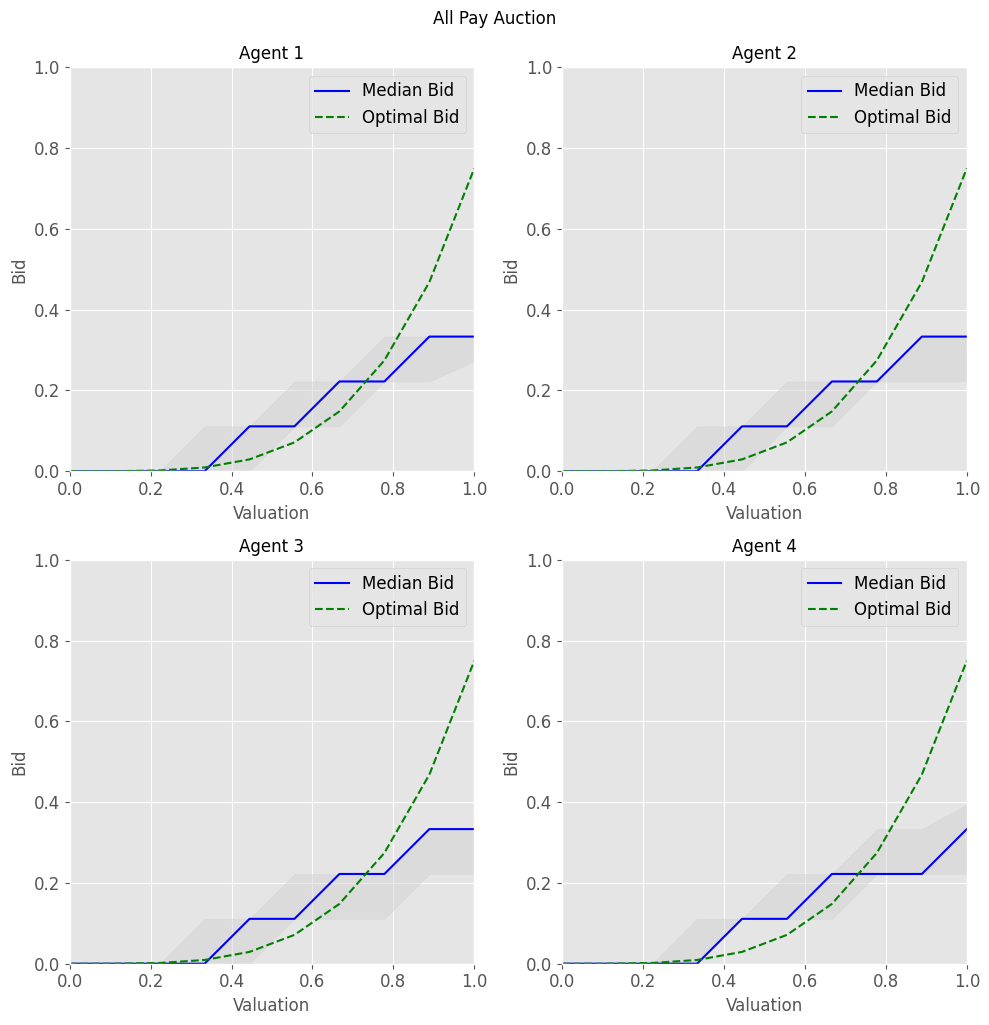

In [37]:
def all_pay_rule(bids):
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
    payment = np.sum(bids)
    return winner, payment

def optimal_bid_all_pay(valuations, N=4):
    return (N-1)/N * valuations**N

agents = [QLearningAgent() for _ in range(4)]
apa_auction = SingleSidedAuction(agents, payment_rule=all_pay_rule,)
percentiles_apa = run_monte_carlo_simulation(agents, apa_auction, num_simulations=30, num_rounds=20000)
plot_monte_carlo_results(agents, percentiles_apa, optimal_bid_rule=optimal_bid_all_pay, title='All Pay Auction')

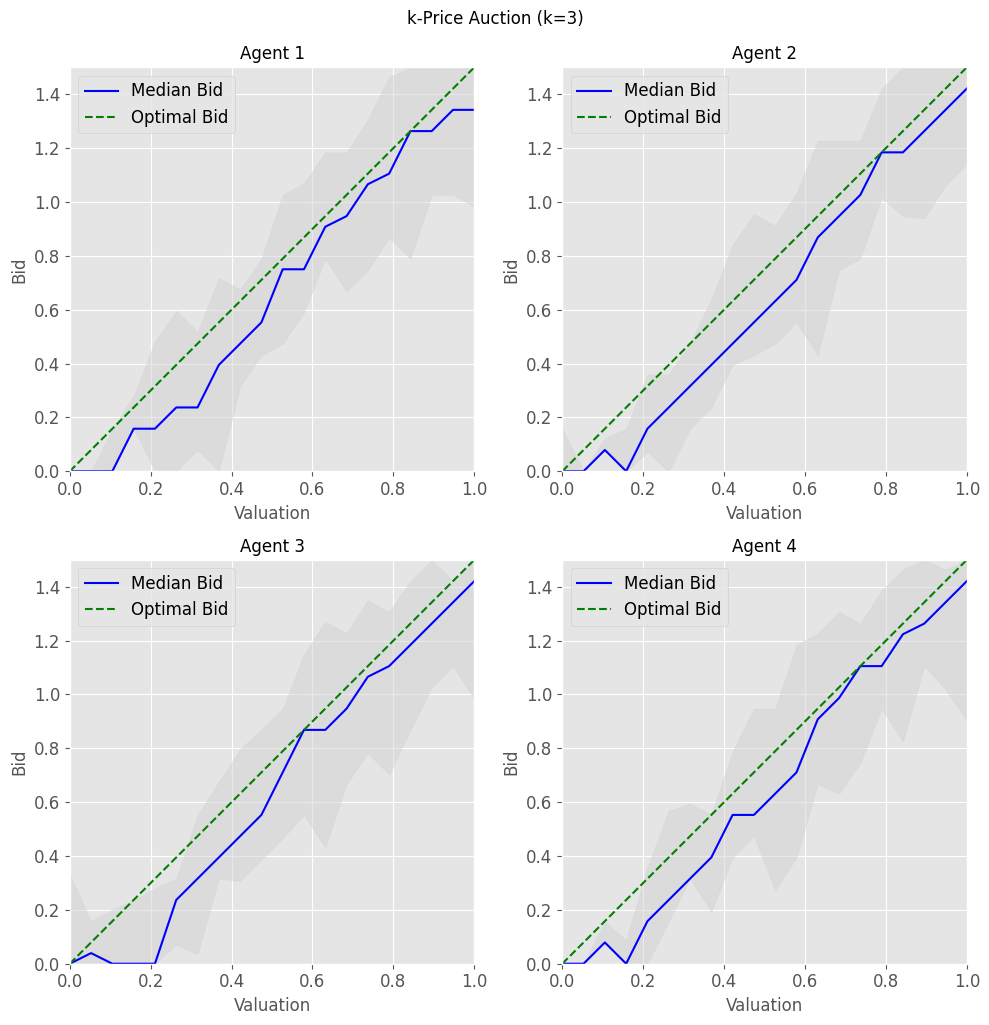

In [5]:
def k_price_rule(bids, k=3):
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
    kth_highest_bid = np.partition(bids, -k)[-k]
    payment = kth_highest_bid
    return winner, payment

def optimal_kpa_rule(valuations, N=4, k=3):
    return (N-1)/(N-k+1) * valuations

agents = [QLearningAgent(action_max=1.5) for _ in range(4)]
kpa_auction = SingleSidedAuction(agents, price_ceiling=1.5, payment_rule=lambda bids: k_price_rule(bids, k=3),)
percentiles_kpa = run_monte_carlo_simulation(agents, kpa_auction, num_simulations=30, num_rounds=20000)
plot_monte_carlo_results(agents, percentiles_kpa, optimal_bid_rule=optimal_kpa_rule, ylim=(0,1.5), title = 'k-Price Auction (k=3)')

/tmp/ipykernel_16114/2258951730.py:15: RuntimeWarning: divide by zero encountered in divide
  return np.where(valuations >= reserve_price, (reserve_price**2 + valuations**2) / (2 * valuations), None)


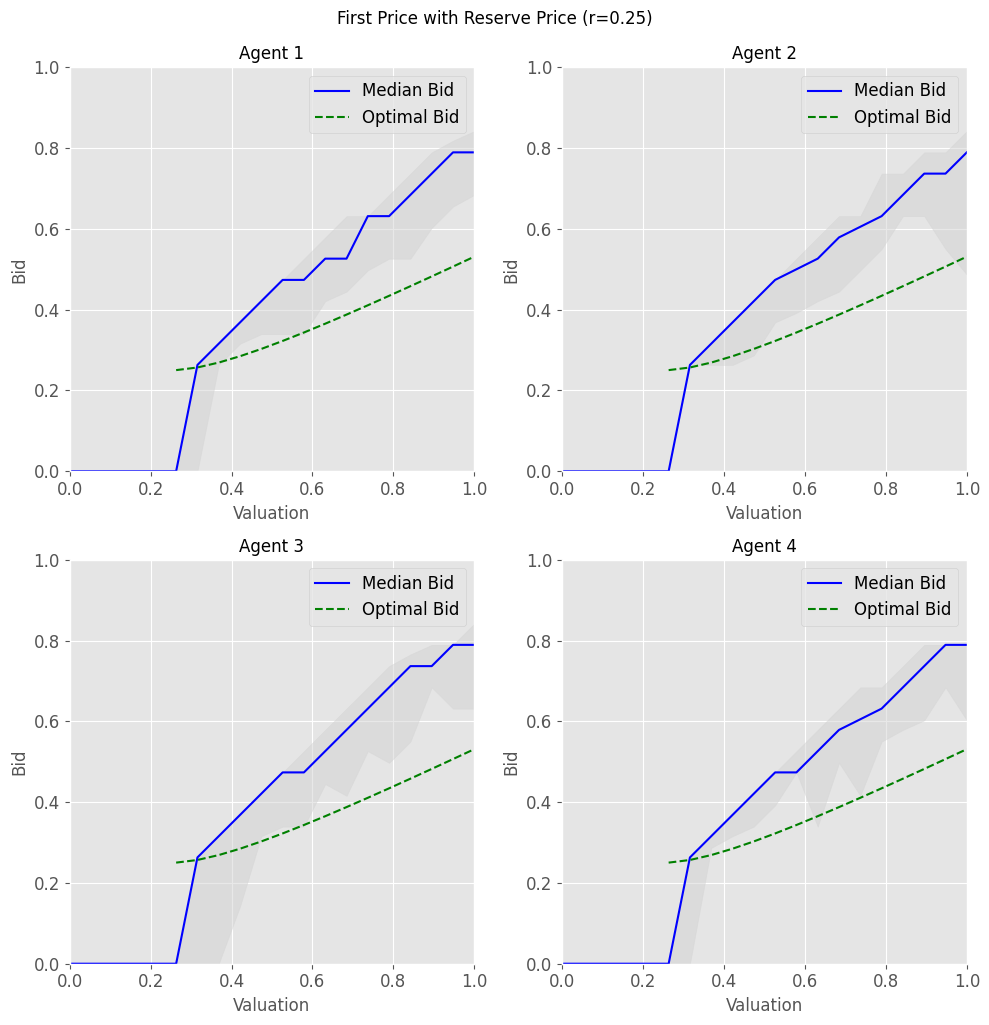

In [6]:
def first_price_with_reserve_rule(bids, reserve_price=0.50):
    bids = np.array(bids)
    valid_bids = bids[bids >= reserve_price]
    if len(valid_bids) > 0:
        max_bid = np.max(valid_bids)
        winner_candidates = np.where(bids == max_bid)[0]
        winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
        payment = bids[winner]
    else:
        winner = None
        payment = 0
    return winner, payment

def optimal_fpa_with_reserve_rule(valuations, reserve_price):
    return np.where(valuations >= reserve_price, (reserve_price**2 + valuations**2) / (2 * valuations), None)

reserve_price = 0.25
agents = [QLearningAgent(action_max=1) for _ in range(4)]
fpa_with_reserve_auction = SingleSidedAuction(
    agents, 
    price_ceiling=1, 
    payment_rule=lambda bids: first_price_with_reserve_rule(bids, reserve_price=reserve_price), 
    epsilon_reward=0.00
)

percentiles_fpa_with_reserve = run_monte_carlo_simulation(agents, fpa_with_reserve_auction, num_simulations=30, num_rounds=20000)
plot_monte_carlo_results(agents, percentiles_fpa_with_reserve,
                         optimal_bid_rule=lambda valuations: optimal_fpa_with_reserve_rule(valuations, reserve_price),
                        title = 'First Price with Reserve Price (r=0.25)')

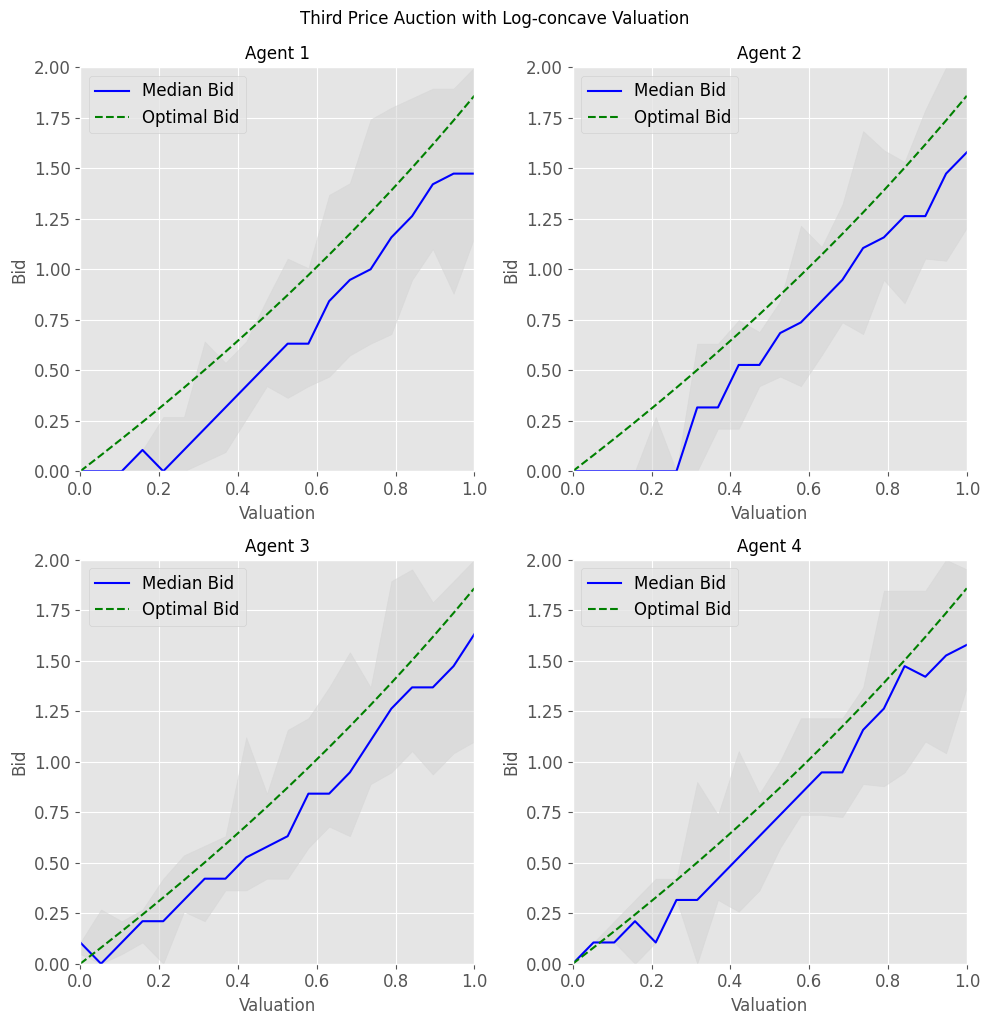

In [9]:
def F_exponential(x, lam=1):
    return 1 - np.exp(-lam * x)

def f_exponential(x, lam=1):
    return lam * np.exp(-lam * x)

def third_price_bid(x, N, lam=1):
    F_x = F_exponential(x, lam)
    f_x = f_exponential(x, lam)
    return x + F_x / ((N - 2) * f_x)

def third_price_rule(bids):
    sorted_bids = np.sort(bids)
    winner = np.argmax(bids)
    payment = sorted_bids[-3]
    return winner, payment

def optimal_third_price_rule(valuations, N=4, lam=1):
    return np.array([third_price_bid(v, N, lam) for v in valuations])

agents_tp = [QLearningAgent(action_max=2) for _ in range(4)]
third_price_auction = SingleSidedAuction(
    agents_tp, 
    price_ceiling=2, 
    payment_rule=third_price_rule,
    epsilon_reward=0.01
)

percentiles_tp = run_monte_carlo_simulation(agents_tp, third_price_auction, num_simulations=30, num_rounds=20000)
plot_monte_carlo_results(agents_tp, percentiles_tp,
                         optimal_bid_rule=lambda valuations: optimal_third_price_rule(valuations, N=4, lam=1), ylim=(0,2.0),
                        title = 'Third Price Auction with Log-concave Valuation')

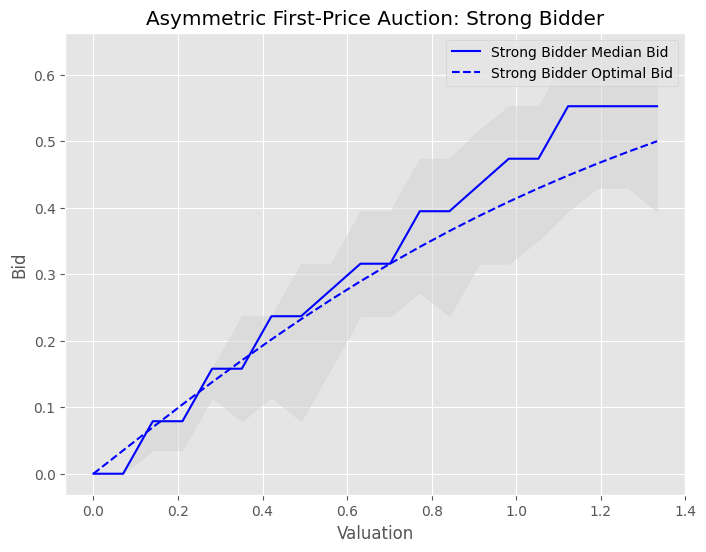

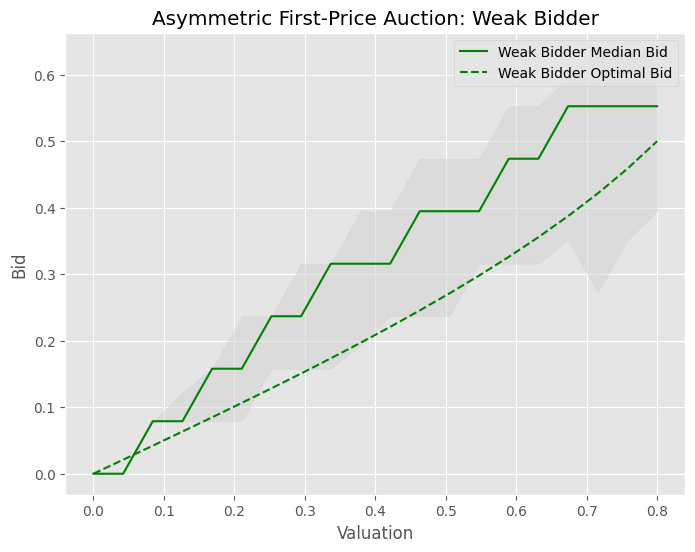

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Define the asymmetric bidding strategy for the first-price auction
def asymmetric_fpa_bid(x, omega_i, omega_j):
    k_i = (1 / omega_i**2) - (1 / omega_j**2)
    if k_i * x**2 >= 1:  # Prevent sqrt of negative numbers
        return np.nan
    if x == 0 or k_i == 0:  # Prevent division by zero
        return 0
    return (1 / (k_i * x)) * (1 - np.sqrt(1 - k_i * x**2))

# First-Price Auction Rule (asymmetric)
def first_price_rule_asymmetric(bids):
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
    payment = bids[winner]
    return winner, payment

# Optimal bid rule for asymmetric first-price auction
def optimal_asymmetric_fpa_rule(valuations, omega1, omega2):
    optimal_bids = np.zeros((len(valuations), 2))
    for i, v in enumerate(valuations):
        optimal_bids[i, 0] = asymmetric_fpa_bid(v, omega1, omega2)  # Strong Bidder
        optimal_bids[i, 1] = asymmetric_fpa_bid(v, omega2, omega1)  # Weak Bidder
    return optimal_bids

# Fix the number of valuations to match Monte Carlo simulation outputs
np.random.seed(0)
omega1, omega2 = 4/3, 4/5

# Generate appropriate valuation ranges for strong and weak bidders
valuations_strong_bidder = np.linspace(0, 4/3, 20)  # Adjusted to match percentile shape (10 elements)
valuations_weak_bidder = np.linspace(0, 4/5, 20)    # Adjusted to match percentile shape (10 elements)

# Set up the Q-learning agents
agents_asymm = [QLearningAgent(action_max=1.5) for _ in range(2)]

# Set up the asymmetric first-price auction
asymmetric_fpa_auction = SingleSidedAuction(
    agents_asymm, 
    price_ceiling=1.5, 
    payment_rule=first_price_rule_asymmetric, 
    epsilon_reward=0.01
)

# Run Monte Carlo simulations for asymmetric first-price auction
percentiles_asymm_fpa = run_monte_carlo_simulation(agents_asymm, asymmetric_fpa_auction, num_simulations=30, num_rounds=20000)

# Calculate the optimal bids for each bidder based on the correct valuation ranges
optimal_bids_strong_bidder = optimal_asymmetric_fpa_rule(valuations_strong_bidder, omega1, omega2)[:, 0]
optimal_bids_weak_bidder = optimal_asymmetric_fpa_rule(valuations_weak_bidder, omega1, omega2)[:, 1]

# Plot for Strong Bidder (Bidder 1)
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.fill_between(valuations_strong_bidder, percentiles_asymm_fpa[0]["5th"], percentiles_asymm_fpa[0]["95th"], color='lightgray', alpha=0.5)
ax1.plot(valuations_strong_bidder, percentiles_asymm_fpa[0]["median"], label='Strong Bidder Median Bid', color='blue')
ax1.plot(valuations_strong_bidder, optimal_bids_strong_bidder, label='Strong Bidder Optimal Bid', color='blue', linestyle='--')
ax1.set_xlabel('Valuation')
ax1.set_ylabel('Bid')
ax1.set_title('Asymmetric First-Price Auction: Strong Bidder')
ax1.legend()
plt.show()

# Plot for Weak Bidder (Bidder 2)
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.fill_between(valuations_weak_bidder, percentiles_asymm_fpa[1]["5th"], percentiles_asymm_fpa[1]["95th"], color='lightgray', alpha=0.5)
ax2.plot(valuations_weak_bidder, percentiles_asymm_fpa[1]["median"], label='Weak Bidder Median Bid', color='green')
ax2.plot(valuations_weak_bidder, optimal_bids_weak_bidder, label='Weak Bidder Optimal Bid', color='green', linestyle='--')
ax2.set_xlabel('Valuation')
ax2.set_ylabel('Bid')
ax2.set_title('Asymmetric First-Price Auction: Weak Bidder')
ax2.legend()
plt.show()